<a href="https://colab.research.google.com/github/OlhaMir/testolha/blob/norma/%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук: лінійна регресія та регуляризація

**Курс:** Машинне навчання  
**Тема:** Linear Regression, Ridge, Lasso, Elastic Net

---


**Студент:** Мірошникова Ольга Ярославівна ФІТ 4-8

Цей ноутбук відповідає лекції про лінійну регресію та побудований як практичне продовження теоретичного матеріалу. У прикладах послідовно розглядаються проста й множинна лінійна регресія, метрики, залишки, недонавчання і перенавчання, L1/L2-регуляризація, Ridge, Lasso, Elastic Net, масштабування, крос-валідація, `GridSearchCV`, `Pipeline`, `ColumnTransformer` та навчальні криві.

У ноутбуці є два типи комірок:

- **Приклад** — готовий код, який потрібно виконати, проаналізувати та пояснити.
- **Самостійне завдання** — окрема кодова комірка з позначкою `TODO`. Її потрібно заповнити власноруч. Готового розв'язку в ноутбуці немає.

Рекомендація: виконувати комірки послідовно зверху вниз і після кожного блоку формулювати короткий висновок своїми словами.

## 0. Імпорт бібліотек і налаштування середовища

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
    learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Середовище готове до роботи.')

Середовище готове до роботи.


## 1. Проста лінійна регресія

Для однієї ознаки модель має вигляд

$$
\hat y = b_0 + b_1x.
$$

Тут $b_0$ — вільний член, а $b_1$ показує, на скільки одиниць у середньому змінюється прогноз $\hat y$ при збільшенні $x$ на одну одиницю.

Нижче згенеруємо дані, у яких істинна залежність приблизно дорівнює $y=5+2.4x$, але спостереження містять випадковий шум.

Вільний член b0: 4.907
Коефіцієнт b1: 2.451


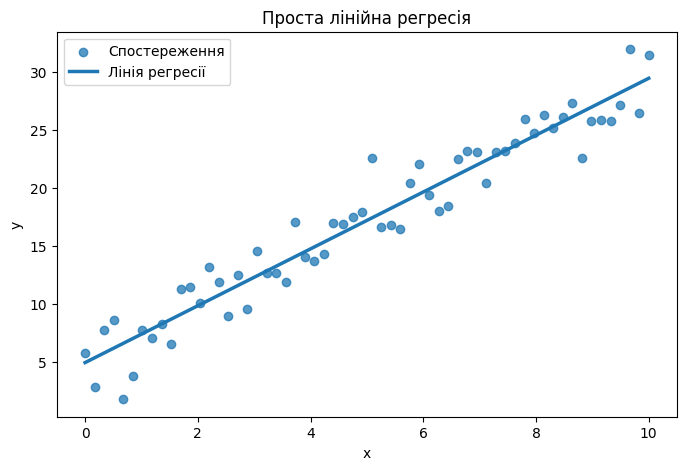

In [2]:
rng = np.random.default_rng(RANDOM_STATE)

X_simple = np.linspace(0, 10, 60).reshape(-1, 1)
y_simple = 5 + 2.4 * X_simple.ravel() + rng.normal(0, 2.5, size=len(X_simple))

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)
y_simple_pred = simple_model.predict(X_simple)

print(f'Вільний член b0: {simple_model.intercept_:.3f}')
print(f'Коефіцієнт b1: {simple_model.coef_[0]:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(X_simple.ravel(), y_simple, alpha=0.75, label='Спостереження')
plt.plot(X_simple.ravel(), y_simple_pred, linewidth=2.5, label='Лінія регресії')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Проста лінійна регресія')
plt.legend()
plt.show()

**Що потрібно побачити.** Коефіцієнт нахилу має бути близьким до 2.4, але не обов'язково дорівнювати йому точно, оскільки дані містять шум. `fit()` оцінює параметри за навчальними даними, а `predict()` лише обчислює прогноз для заданих значень ознак.

### Самостійне завдання 1

1. Створіть новий масив `X_new` зі значеннями 2, 5 і 8.
2. Отримайте прогнози моделі.
3. Виведіть таблицю з колонками `x` та `prediction`.
4. Одним реченням поясніть зміст отриманого коефіцієнта `b1`.

In [7]:
# TODO: Самостійне завдання 1

X_new = np.array([2, 5, 8]).reshape(-1, 1)

predictions = simple_model.predict(X_new)

result = pd.DataFrame({
    'x': X_new.ravel(),
    'prediction': predictions
})

result['prediction'] = result['prediction'].round(3)
print(result)

print(f"\nКоефіцієнт b1 показує, наскільки в середньому змінюється y при збільшенні x на 1 одиницю.")

   x  prediction
0  2       9.810
1  5      17.163
2  8      24.517

Коефіцієнт b1 показує, наскільки в середньому змінюється y при збільшенні x на 1 одиницю.


## 2. Метод найменших квадратів і ручний розрахунок коефіцієнтів

Для простої регресії коефіцієнт нахилу можна обчислити без готової моделі:

$$
b_1 = \frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2},
\qquad
b_0 = \bar y-b_1\bar x.
$$

Чисельник у формулі для $b_1$ відображає спільну зміну $x$ і $y$, а знаменник — варіативність самої ознаки $x$. Після знаходження нахилу вільний член підбирається так, щоб пряма проходила через точку $(\bar x, \bar y)$.

In [9]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3.0, 5.2, 6.8, 9.1, 10.9])

x_bar = x.mean()
y_bar = y.mean()

b1_manual = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0_manual = y_bar - b1_manual * x_bar

model_check = LinearRegression().fit(x.reshape(-1, 1), y)

print(f'Ручний розрахунок: b0={b0_manual:.4f}, b1={b1_manual:.4f}')
print(f'scikit-learn:     b0={model_check.intercept_:.4f}, b1={model_check.coef_[0]:.4f}')

Ручний розрахунок: b0=1.0900, b1=1.9700
scikit-learn:     b0=1.0900, b1=1.9700


### Самостійне завдання 2

Використайте масиви `x2 = [2, 4, 6, 8, 10]` та `y2 = [7, 11, 16, 19, 25]`. Власноруч обчисліть `b0` і `b1` за формулами, а потім перевірте результат за допомогою `LinearRegression`.

In [10]:
# Самостійне завдання 2

x2 = np.array([2, 4, 6, 8, 10], dtype=float)
y2 = np.array([7, 11, 16, 19, 25], dtype=float)

x2_bar = x2.mean()
y2_bar = y2.mean()

b1_2 = ((x2 - x2_bar) * (y2 - y2_bar)).sum() / ((x2 - x2_bar) ** 2).sum()
b0_2 = y2_bar - b1_2 * x2_bar

model2 = LinearRegression()
model2.fit(x2.reshape(-1, 1), y2)

print(f'Середнє x: {x2_bar:.4f}')
print(f'Середнє y: {y2_bar:.4f}')

print(f'\nРучний розрахунок: b0={b0_2:.4f}, b1={b1_2:.4f}')
print(f'scikit-learn:     b0={model2.intercept_:.4f}, b1={model2.coef_[0]:.4f}')

Середнє x: 6.0000
Середнє y: 15.6000

Ручний розрахунок: b0=2.4000, b1=2.2000
scikit-learn:     b0=2.4000, b1=2.2000


## 3. Множинна лінійна регресія

У випадку кількох ознак модель має вигляд

$$
\hat y = b_0+b_1x_1+b_2x_2+\dots+b_px_p.
$$

Коефіцієнт $b_j$ інтерпретується як зміна прогнозу при збільшенні ознаки $x_j$ на одну одиницю **за інших рівних умов**, тобто при фіксованих значеннях інших ознак.

Для практики використаємо вбудований набір `diabetes`, тому ноутбук не потребує завантаження даних з Інтернету.

In [11]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data.copy()
y = diabetes.target.copy()

print('Розмір X:', X.shape)
print('Розмір y:', y.shape)
display(X.head())

Розмір X: (442, 10)
Розмір y: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [12]:
y

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [13]:
multi_model = LinearRegression()
multi_model.fit(X, y)

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': multi_model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

display(coef_table)
print(f'Intercept: {multi_model.intercept_:.3f}')

,feature,coefficient
4,s1,-792.175639
8,s5,751.273700
2,bmi,519.845920
5,s2,476.739021
3,bp,324.384646
1,sex,-239.815644
7,s4,177.063238
6,s3,101.043268
9,s6,67.626692
0,age,-10.009866


Intercept: 152.133


Зверніть увагу: великий за модулем коефіцієнт не завжди означає, що ознака є «найважливішою». Порівняння коефіцієнтів залежить від масштабу ознак та їх взаємної кореляції.

## 4. Train/test та наївний baseline

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)



`DummyRegressor` не використовує закономірності в ознаках і в цьому прикладі прогнозує середнє значення цільової змінної з train. Якщо реальна модель не перевершує такий baseline, необхідно переглянути ознаки, постановку задачі або сам алгоритм.

## 5. Метрики якості регресії

У лекції розглядалися MAE, MSE, RMSE та $R^2$. Вони відповідають на різні питання.

- **MAE** показує середню абсолютну величину помилки.
- **MSE** сильніше штрафує великі помилки через піднесення залишку до квадрата.
- **RMSE** є коренем з MSE і вимірюється в тих самих одиницях, що й цільова змінна.
- **$R^2$** порівнює модель із прогнозом середнім значенням цільової змінної. На нових даних він може бути від'ємним.

In [15]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': (np.abs(y_true - y_pred) / y_true).mean() * 100
    }

metrics_baseline = regression_metrics(y_test, baseline_pred)
metrics_linear = regression_metrics(y_test, linear_pred)

pd.DataFrame([metrics_baseline, metrics_linear], index=['DummyRegressor', 'LinearRegression'])

,MAE,MSE,RMSE,R2,MAPE
DummyRegressor,64.006461,5361.533457,73.222493,-0.011963,62.791796
LinearRegression,42.794095,2900.193628,53.853446,0.452603,37.499826


### Самостійне завдання 3

Обчисліть MAE, RMSE і $R^2$ окремо, **не використовуючи** функцію `regression_metrics`. Порівняйте `DummyRegressor` і `LinearRegression`. У Markdown-комірці нижче поясніть, яка модель краща і чому не варто робити висновок лише за однією метрикою.

In [16]:
# Самостійне завдання 3

mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = root_mean_squared_error(y_test, baseline_pred)
r2_baseline = r2_score(y_test, baseline_pred)

mae_linear = mean_absolute_error(y_test, linear_pred)
rmse_linear = root_mean_squared_error(y_test, linear_pred)
r2_linear = r2_score(y_test, linear_pred)

print('DummyRegressor:')
print(f'MAE  = {mae_baseline:.4f}')
print(f'RMSE = {rmse_baseline:.4f}')
print(f'R2   = {r2_baseline:.4f}')

print('\nLinearRegression:')
print(f'MAE  = {mae_linear:.4f}')
print(f'RMSE = {rmse_linear:.4f}')
print(f'R2   = {r2_linear:.4f}')

DummyRegressor:
MAE  = 64.0065
RMSE = 73.2225
R2   = -0.0120

LinearRegression:
MAE  = 42.7941
RMSE = 53.8534
R2   = 0.4526


**Висновок**

LinearRegression є кращою моделлю, якщо вона має менші значення MAE та RMSE і більше значення R2 порівняно з DummyRegressor. MAE і RMSE показують величину помилки прогнозу, а R2 показує, яку частину варіації цільової змінної пояснює модель. Не варто робити висновок лише за однією метрикою, оскільки кожна метрика оцінює якість моделі з іншого боку.

## 6. Залишки та діагностика моделі

Залишок для об'єкта визначається як

$$
e_i = y_i-\hat y_i.
$$

Якщо модель добре описує систематичну частину залежності, на графіку `prediction → residual` не повинно бути вираженої структури. Дуга може вказувати на нелінійність, а «воронка» — на зміну дисперсії помилки.

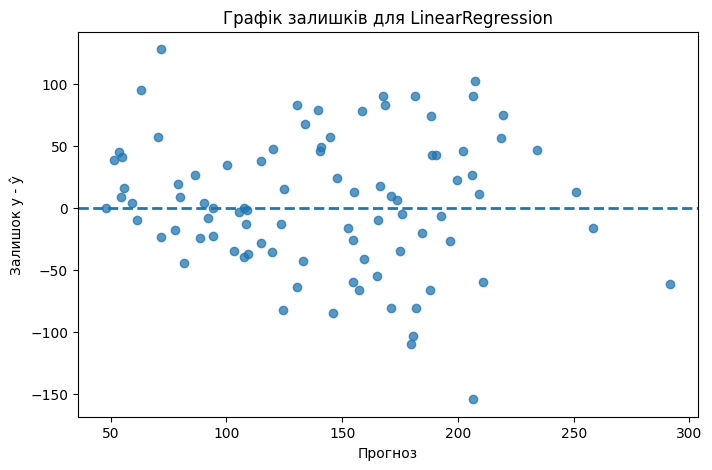

In [17]:
residuals = y_test - linear_pred

plt.figure(figsize=(8, 5))
plt.scatter(linear_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle='--', linewidth=2)
plt.xlabel('Прогноз')
plt.ylabel('Залишок y - ŷ')
plt.title('Графік залишків для LinearRegression')
plt.show()

## 7. Недонавчання і перенавчання на поліноміальній регресії

Лінійна модель може недонавчатися, якщо реальна залежність нелінійна. Один зі способів збільшити гнучкість — створити поліноміальні ознаки. Але занадто високий ступінь полінома збільшує ризик перенавчання.

Порівняємо ступені 1, 4 і 15 на невеликій синтетичній вибірці.

In [18]:
rng = np.random.default_rng(RANDOM_STATE)
X_poly = np.sort(rng.uniform(-3, 3, 45)).reshape(-1, 1)
y_true_poly = np.sin(X_poly.ravel()) + 0.25 * X_poly.ravel()
y_poly = y_true_poly + rng.normal(0, 0.22, size=len(X_poly))

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_poly, y_poly, test_size=0.35, random_state=RANDOM_STATE
)

def fit_polynomial(degree):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression()),
    ])
    model.fit(X_p_train, y_p_train)
    train_pred = model.predict(X_p_train)
    test_pred = model.predict(X_p_test)
    return model, {
        'degree': degree,
        'train_rmse': root_mean_squared_error(y_p_train, train_pred),
        'test_rmse': root_mean_squared_error(y_p_test, test_pred),
    }

results = []
models_poly = {}
for degree in [1, 4, 15]:
    m, res = fit_polynomial(degree)
    models_poly[degree] = m
    results.append(res)

pd.DataFrame(results)

,degree,train_rmse,test_rmse
0,1,0.392868,0.465437
1,4,0.144969,0.203183
2,15,0.091024,0.244266


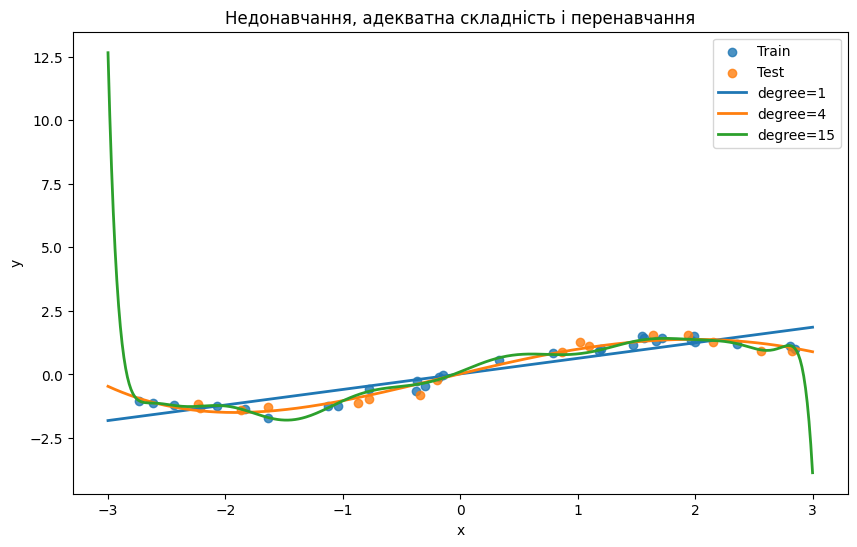

In [19]:
grid = np.linspace(-3, 3, 400).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_p_train, y_p_train, label='Train', alpha=0.8)
plt.scatter(X_p_test, y_p_test, label='Test', alpha=0.8)

for degree in [1, 4, 15]:
    plt.plot(grid, models_poly[degree].predict(grid), linewidth=2, label=f'degree={degree}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Недонавчання, адекватна складність і перенавчання')
plt.legend()
plt.show()

### Самостійне завдання 4

1. Додайте до порівняння ступені 2, 6 і 10.
2. Побудуйте таблицю `degree`, `train_rmse`, `test_rmse`.
3. Визначте ступінь із найменшим `test_rmse`.
4. Поясніть, чому мінімальна train-помилка не гарантує найкращої моделі.

In [20]:
# Самостійне завдання 4

results = []
models_poly = {}

for degree in [1, 2, 4, 6, 10, 15]:
    m, res = fit_polynomial(degree)
    models_poly[degree] = m
    results.append(res)

results_df = pd.DataFrame(results)

print(results_df)

best_degree = results_df.loc[results_df['test_rmse'].idxmin(), 'degree']
best_test_rmse = results_df['test_rmse'].min()

print(f'\nНайкращий ступінь полінома: {best_degree}')
print(f'Найменший test RMSE: {best_test_rmse:.4f}')

   degree  train_rmse  test_rmse
0       1    0.392868   0.465437
1       2    0.392821   0.463992
2       4    0.144969   0.203183
3       6    0.137065   0.196267
4      10    0.129074   0.191782
5      15    0.091024   0.244266

Найкращий ступінь полінома: 10
Найменший test RMSE: 0.1918


**Висновок**

Найкращим вважається ступінь полінома, для якого test RMSE має найменше значення. Мінімальна помилка на навчальних даних не гарантує найкращої моделі, оскільки складна модель може перенавчитися на train-вибірці та погано працювати на нових даних. Тому для порівняння моделей важливо враховувати помилку на тестових даних.

## 8. Регуляризація: загальна ідея

Коли модель має багато ознак або ознаки сильно корельовані, коефіцієнти можуть ставати нестабільними. Регуляризація додає до функції втрат штраф за великі коефіцієнти.

Для Ridge використовується L2-штраф

$$
\text{MSE}+\alpha\sum_{j=1}^{p} b_j^2,
$$

для Lasso — L1-штраф

$$
\text{MSE}+\alpha\sum_{j=1}^{p}|b_j|.
$$

Параметр $\alpha$ керує силою регуляризації. Якщо $\alpha=0$, штраф зникає. Надто велике $\alpha$ може надмірно стиснути коефіцієнти й спричинити недонавчання.

## 9. Чому перед Ridge, Lasso та Elastic Net потрібне масштабування

In [21]:
# Штучно змінюємо масштаби кількох ознак, щоб побачити роль StandardScaler.
X_scaled_demo = X.copy()
X_scaled_demo['bmi'] = X_scaled_demo['bmi'] * 1000
X_scaled_demo['bp'] = X_scaled_demo['bp'] * 0.01

Xsd_train, Xsd_test, ysd_train, ysd_test = train_test_split(
    X_scaled_demo, y, test_size=0.2, random_state=RANDOM_STATE
)

ridge_no_scaling = Ridge(alpha=10.0).fit(Xsd_train, ysd_train)
ridge_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=10.0)),
]).fit(Xsd_train, ysd_train)

print('Ridge без масштабування RMSE:', root_mean_squared_error(ysd_test, ridge_no_scaling.predict(Xsd_test)))
print('Ridge + StandardScaler RMSE:', root_mean_squared_error(ysd_test, ridge_pipeline.predict(Xsd_test)))

Ridge без масштабування RMSE: 62.25349241861679
Ridge + StandardScaler RMSE: 53.626287568895194


Штраф застосовується безпосередньо до коефіцієнтів. Якщо ознаки вимірюються в дуже різних масштабах, одна й та сама величина коефіцієнта не має однакового змісту. Тому `StandardScaler` зазвичай включають у `Pipeline` перед регуляризованою лінійною моделлю.

## 10. Ridge-регресія: L2-регуляризація

In [22]:
ridge = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print(regression_metrics(y_test, ridge_pred))

{'MAE': 42.81199941834889, 'MSE': 2892.0145657501726, 'RMSE': 53.777454065343896, 'R2': 0.45414652070698225, 'MAPE': np.float64(37.44816405198748)}


## 11. Lasso: L1-регуляризація

In [23]:
lasso = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(alpha=1.0, max_iter=20000)),
])

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

lasso_coef = lasso.named_steps['reg'].coef_
print(regression_metrics(y_test, lasso_pred))
print('Кількість нульових коефіцієнтів:', np.sum(np.isclose(lasso_coef, 0)))

{'MAE': 42.80298373195777, 'MSE': 2824.568094049959, 'RMSE': 53.14666587896139, 'R2': 0.46687670944102466, 'MAPE': np.float64(37.43982076869067)}
Кількість нульових коефіцієнтів: 1


На відміну від Ridge, Lasso може занулювати частину коефіцієнтів. Саме тому L1-регуляризацію іноді використовують як вбудований механізм відбору ознак. Проте при сильно корельованих предикторах вибір конкретної ознаки може бути нестабільним.

## 12. Elastic Net: поєднання L1 та L2

In [24]:
elastic = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)),
])

elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

print(regression_metrics(y_test, elastic_pred))

{'MAE': 42.873332243316874, 'MSE': 2866.4612552977674, 'RMSE': 53.539343060013046, 'R2': 0.4589695819678379, 'MAPE': np.float64(37.40678706534485)}


В Elastic Net параметр `alpha` визначає загальну силу регуляризації, а `l1_ratio` — співвідношення між L1 та L2. Значення `l1_ratio=1` наближає модель до Lasso, а `l1_ratio=0` — до Ridge.

### Самостійне завдання 5

Навчіть на одному й тому самому train/test розбитті чотири моделі: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`. Для регуляризованих моделей використайте `StandardScaler` у `Pipeline`. Побудуйте таблицю з MAE, RMSE та $R^2$.

In [25]:
# Самостійне завдання 5

# 1. LinearRegression
linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)

# 2. Ridge + StandardScaler
ridge = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# 3. Lasso + StandardScaler
lasso = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(alpha=1.0, max_iter=20000))
])
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# 4. ElasticNet + StandardScaler
elastic = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000))
])
elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

results = pd.DataFrame({
    'Model': [
        'LinearRegression',
        'Ridge',
        'Lasso',
        'ElasticNet'
    ],
    'MAE': [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, elastic_pred)
    ],
    'RMSE': [
        root_mean_squared_error(y_test, linear_pred),
        root_mean_squared_error(y_test, ridge_pred),
        root_mean_squared_error(y_test, lasso_pred),
        root_mean_squared_error(y_test, elastic_pred)
    ],
    'R2': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ]
})

results[['MAE', 'RMSE', 'R2']] = results[['MAE', 'RMSE', 'R2']].round(4)

print(results)

              Model      MAE     RMSE      R2
0  LinearRegression  42.7941  53.8534  0.4526
1             Ridge  42.8120  53.7775  0.4541
2             Lasso  42.8030  53.1467  0.4669
3        ElasticNet  42.8733  53.5393  0.4590


## 13. Крос-валідація

Одне train/test розбиття залежить від випадкового поділу. K-fold cross-validation кілька разів змінює validation-частину і дає більш стійку оцінку якості моделі. Важливо, що preprocessing повинен бути всередині `Pipeline`, щоб на кожному фолді параметри масштабування оцінювалися лише з train-частини.

In [26]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_cv_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])

scores = cross_validate(
    ridge_cv_model,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
    return_train_score=True,
)

cv_table = pd.DataFrame({
    'fold': np.arange(1, 6),
    'train_R2': scores['train_r2'],
    'val_R2': scores['test_r2'],
    'val_MAE': -scores['test_mae'],
    'val_RMSE': -scores['test_rmse'],
})

display(cv_table)
print('Середній validation RMSE:', cv_table['val_RMSE'].mean())

,fold,train_R2,val_R2,val_MAE,val_RMSE
0,1,0.527632,0.454147,42.811999,53.777454
1,2,0.497124,0.571674,41.616638,51.692906
2,3,0.538901,0.391921,47.224871,57.530264
3,4,0.494045,0.583169,42.166318,52.966248
4,5,0.540152,0.394449,47.397540,58.168400


Середній validation RMSE: 54.827054212084306


## 14. Підбір alpha для Ridge за GridSearchCV

In [27]:
ridge_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge()),
])

param_grid_ridge = {
    'reg__alpha': np.logspace(0, 5, 13)
}

ridge_search = GridSearchCV(
    ridge_search_model,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)

print('Найкраще alpha:', ridge_search.best_params_['reg__alpha'])
print('CV RMSE:', -ridge_search.best_score_)
print('Test RMSE:', root_mean_squared_error(y_test, ridge_search.predict(X_test)))

Найкраще alpha: 1.0
CV RMSE: 55.374175368673455
Test RMSE: 53.777454065343896


Тестову вибірку не використовують для підбору `alpha`. Гіперпараметр обирається всередині train за крос-валідацією, а test використовується лише після завершення вибору моделі.

## 15. Підбір alpha і l1_ratio для Elastic Net

In [28]:
elastic_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(max_iter=30000)),
])

param_grid_elastic = {
    'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
    'reg__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

elastic_search = GridSearchCV(
    elastic_search_model,
    param_grid=param_grid_elastic,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

elastic_search.fit(X_train, y_train)

print('Найкращі параметри:', elastic_search.best_params_)
print('CV RMSE:', -elastic_search.best_score_)
print('Test RMSE:', root_mean_squared_error(y_test, elastic_search.predict(X_test)))

Найкращі параметри: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9}
CV RMSE: 55.36852020555442
Test RMSE: 53.74450007977087


### Самостійне завдання 6

Виконайте `GridSearchCV` для Lasso. Перевірте не менше 10 значень `alpha` у логарифмічній шкалі. Порівняйте найкращий Lasso з найкращим Ridge за однаковою схемою CV.

In [29]:
# Самостійне завдання 6

lasso_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(max_iter=30000)),
])

param_grid_lasso = {
    'reg__alpha': np.logspace(-3, 1, 13)
}

lasso_search = GridSearchCV(
    lasso_search_model,
    param_grid=param_grid_lasso,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

lasso_search.fit(X_train, y_train)

lasso_test_pred = lasso_search.predict(X_test)

print('Найкраще alpha для Lasso:', lasso_search.best_params_['reg__alpha'])
print('Lasso CV RMSE:', -lasso_search.best_score_)
print('Lasso Test RMSE:', root_mean_squared_error(y_test, lasso_test_pred))

ridge_test_pred = ridge_search.predict(X_test)

print('\n--- Порівняння ---')
print(f'Ridge CV RMSE:  {-ridge_search.best_score_:.4f}')
print(f'Ridge Test RMSE: {root_mean_squared_error(y_test, ridge_test_pred):.4f}')

print(f'\nLasso CV RMSE:   {-lasso_search.best_score_:.4f}')
print(f'Lasso Test RMSE: {root_mean_squared_error(y_test, lasso_test_pred):.4f}')

Найкраще alpha для Lasso: 0.1
Lasso CV RMSE: 55.353957634803294
Lasso Test RMSE: 53.70869844573793

--- Порівняння ---
Ridge CV RMSE:  55.3742
Ridge Test RMSE: 53.7775

Lasso CV RMSE:   55.3540
Lasso Test RMSE: 53.7087


## 16. Як регуляризація змінює коефіцієнти

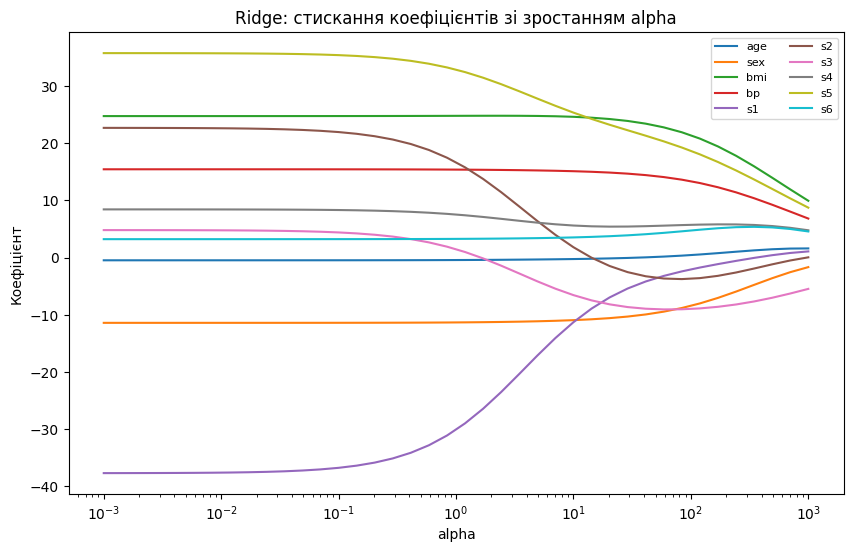

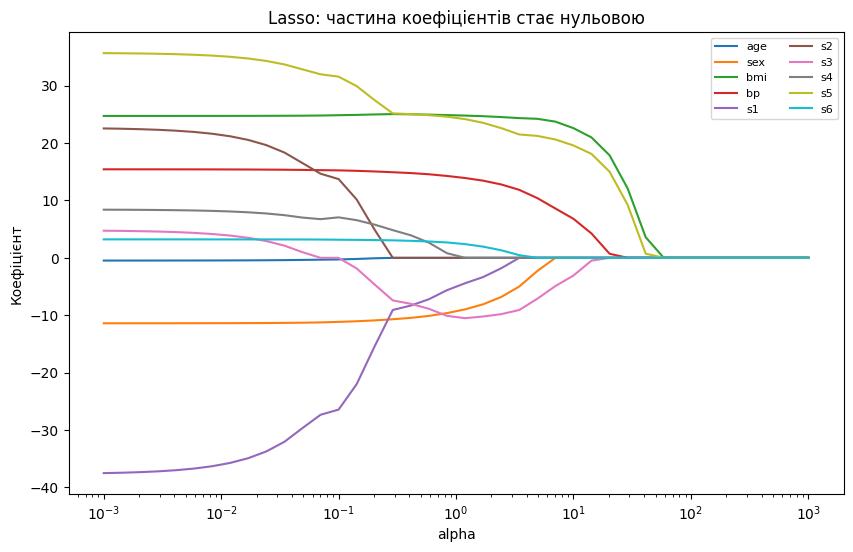

In [30]:
alphas = np.logspace(-3, 3, 40)
ridge_paths = []
lasso_paths = []

X_for_path = StandardScaler().fit_transform(X)

for alpha in alphas:
    ridge_m = Ridge(alpha=alpha).fit(X_for_path, y)
    lasso_m = Lasso(alpha=alpha, max_iter=30000).fit(X_for_path, y)
    ridge_paths.append(ridge_m.coef_)
    lasso_paths.append(lasso_m.coef_)

ridge_paths = np.array(ridge_paths)
lasso_paths = np.array(lasso_paths)

plt.figure(figsize=(10, 6))
for j, name in enumerate(X.columns):
    plt.plot(alphas, ridge_paths[:, j], label=name)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коефіцієнт')
plt.title('Ridge: стискання коефіцієнтів зі зростанням alpha')
plt.legend(ncol=2, fontsize=8)
plt.show()

plt.figure(figsize=(10, 6))
for j, name in enumerate(X.columns):
    plt.plot(alphas, lasso_paths[:, j], label=name)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коефіцієнт')
plt.title('Lasso: частина коефіцієнтів стає нульовою')
plt.legend(ncol=2, fontsize=8)
plt.show()

Ці графіки демонструють ключову різницю. Ridge плавно стискає коефіцієнти до нуля, тоді як Lasso може зробити частину з них точно нульовими.

## 17. Мультиколінеарність і стабільність коефіцієнтів

In [31]:
rng = np.random.default_rng(RANDOM_STATE)
n = 250
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(scale=0.03, size=n)  # дуже сильна кореляція
x3 = rng.normal(size=n)
y_corr = 5 * x1 + 5 * x2 + 0.5 * x3 + rng.normal(scale=1.5, size=n)

X_corr = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
print(X_corr.corr())

ols_corr = LinearRegression().fit(X_corr, y_corr)
ridge_corr = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=10.0)),
]).fit(X_corr, y_corr)

coef_compare = pd.DataFrame({
    'feature': X_corr.columns,
    'OLS': ols_corr.coef_,
    'Ridge_scaled': ridge_corr.named_steps['reg'].coef_,
})
coef_compare

          x1        x2        x3
x1  1.000000  0.999515 -0.008921
x2  0.999515  1.000000 -0.010420
x3 -0.008921 -0.010420  1.000000


,feature,OLS,Ridge_scaled
0,x1,5.446248,4.546617
1,x2,4.410887,4.534370
2,x3,0.444792,0.439193


За наявності дуже корельованих ознак окремі коефіцієнти OLS можуть бути нестабільними: невеликі зміни даних здатні суттєво змінити їх значення. Ridge зменшує variance коефіцієнтів завдяки L2-штрафу.

## 18. Категоріальні ознаки, пропуски та ColumnTransformer

У реальній табличній задачі дані часто містять числові й категоріальні ознаки, а також пропуски. Їх потрібно обробляти всередині `Pipeline`, щоб не створювати витік інформації.

In [32]:
rng = np.random.default_rng(RANDOM_STATE)
n = 300

housing = pd.DataFrame({
    'area': rng.normal(75, 20, n).clip(25, 150),
    'rooms': rng.integers(1, 6, n),
    'age': rng.integers(0, 70, n).astype(float),
    'district': rng.choice(['center', 'north', 'south'], n, p=[0.3, 0.35, 0.35]),
})

# Додаємо кілька пропусків.
housing.loc[rng.choice(n, 18, replace=False), 'age'] = np.nan

price = (
    1500 * housing['area']
    + 7000 * housing['rooms']
    - 500 * housing['age'].fillna(housing['age'].median())
    + housing['district'].map({'center': 40000, 'north': 12000, 'south': 0})
    + rng.normal(0, 12000, n)
)

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    housing, price, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = ['area', 'rooms', 'age']
categorical_features = ['district']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

housing_model = Pipeline([
    ('prep', preprocessor),
    ('reg', Ridge(alpha=1.0)),
])

housing_model.fit(X_h_train, y_h_train)
housing_pred = housing_model.predict(X_h_test)

print('Housing RMSE:', root_mean_squared_error(y_h_test, housing_pred))
print('Housing R2:', r2_score(y_h_test, housing_pred))
print('Housing MAE:', mean_absolute_error(y_h_test, housing_pred))
print('MAPE', mean_absolute_percentage_error(y_h_test, housing_pred))

Housing RMSE: 10925.278371503928
Housing R2: 0.9068908686435069
Housing MAE: 8737.023097309464
MAPE 0.07276440135248957


In [33]:
housing

,area,rooms,age,district
0,81.094342,4,17.0,south
1,54.200318,2,66.0,south
2,90.009024,2,37.0,center
3,93.811294,2,21.0,south
4,35.979296,3,29.0,south
...,...,...,...,...
295,78.530248,4,30.0,center
296,80.919880,5,45.0,center
297,67.561708,3,38.0,center
298,39.865564,3,67.0,south


In [34]:
price

,0
0,146888.018855
1,43872.771974
2,175189.836338
3,145447.579696
4,58699.634461
...,...
295,179796.834387
296,197085.341513
297,166868.377770
298,32562.347956


### Самостійне завдання 7

Додайте до таблиці `housing` нову категоріальну ознаку `condition` зі значеннями `new`, `good`, `needs_repair`. Включіть її в `ColumnTransformer`, перенавчіть модель і перевірте, чи змінилася test-помилка.

In [35]:
# Самостійне завдання 7

old_rmse = root_mean_squared_error(y_h_test, housing_pred)

housing['condition'] = rng.choice(
    ['new', 'good', 'needs_repair'],
    n,
    p=[0.3, 0.5, 0.2]
)

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    housing,
    price,
    test_size=0.2,
    random_state=RANDOM_STATE
)

categorical_features_new = ['district', 'condition']

categorical_pipe_new = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor_new = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe_new, categorical_features_new),
])

housing_model_new = Pipeline([
    ('prep', preprocessor_new),
    ('reg', Ridge(alpha=1.0)),
])

housing_model_new.fit(X_h_train, y_h_train)

housing_pred_new = housing_model_new.predict(X_h_test)

new_rmse = root_mean_squared_error(y_h_test, housing_pred_new)
new_r2 = r2_score(y_h_test, housing_pred_new)
new_mae = mean_absolute_error(y_h_test, housing_pred_new)

print('Результати нової моделі:')
print(f'RMSE: {new_rmse:.4f}')
print(f'R2:   {new_r2:.4f}')
print(f'MAE:  {new_mae:.4f}')

print('\nПорівняння RMSE:')
print(f'Стара модель: {old_rmse:.4f}')
print(f'Нова модель:  {new_rmse:.4f}')

if new_rmse < old_rmse:
    print('Test RMSE зменшився — нова модель краща.')
elif new_rmse > old_rmse:
    print('Test RMSE збільшився — нова модель гірша.')
else:
    print('Test RMSE не змінився.')

Результати нової моделі:
RMSE: 11041.9991
R2:   0.9049
MAE:  8840.9429

Порівняння RMSE:
Стара модель: 10925.2784
Нова модель:  11041.9991
Test RMSE збільшився — нова модель гірша.


**Висновок**

До набору даних було додано нову категоріальну ознаку `condition`, яка має три значення: `new`, `good` та `needs_repair`. Для її обробки використано `OneHotEncoder`, а ознаку було включено до `ColumnTransformer`. Після перенавчання моделі було порівняно значення Test RMSE старої та нової моделей. Якщо RMSE нової моделі менше, додавання ознаки `condition` покращило якість прогнозування.

## 19. Навчальні криві

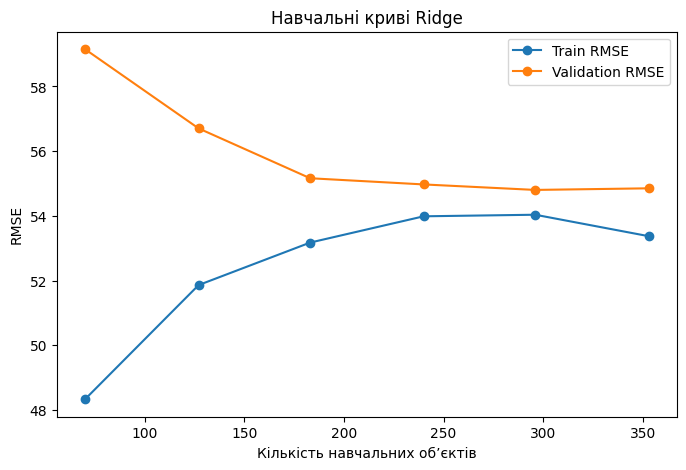

In [36]:
learning_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=ridge_search.best_params_['reg__alpha'])),
])

train_sizes, train_scores, val_scores = learning_curve(
    learning_model,
    X,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1,
)

train_rmse_curve = -train_scores.mean(axis=1)
val_rmse_curve = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse_curve, marker='o', label='Validation RMSE')
plt.xlabel('Кількість навчальних об’єктів')
plt.ylabel('RMSE')
plt.title('Навчальні криві Ridge')
plt.legend()
plt.show()

Якщо train і validation помилки високі та близькі, це ознака можливого недонавчання. Якщо train-помилка значно нижча за validation, це може свідчити про високу variance та перенавчання. Навчальні криві допомагають зрозуміти, чи може збільшення обсягу даних бути корисним.

## 20. Повний приклад: коректний вибір моделі без використання test

In [37]:
# 1. Test відкладаємо один раз.
X_final_train, X_final_test, y_final_train, y_final_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# 2. Вибір моделі відбувається тільки всередині train за CV.
model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(max_iter=30000)),
])

param_grid = {
    'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
    'reg__l1_ratio': [0.1, 0.5, 0.9],
}

search = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
)
search.fit(X_final_train, y_final_train)

# 3. Лише після завершення підбору оцінюємо test.
final_pred = search.predict(X_final_test)

print('Найкращі параметри:', search.best_params_)
print('CV RMSE:', -search.best_score_)
print('Test metrics:', regression_metrics(y_final_test, final_pred))

Найкращі параметри: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9}
CV RMSE: 55.36852020555442
Test metrics: {'MAE': 42.81393247843441, 'MSE': 2888.4712888244917, 'RMSE': 53.74450007977087, 'R2': 0.4548152967432053, 'MAPE': np.float64(37.42858410670238)}


# 21. Підсумкове практичне завдання для самостійної роботи

Виконайте повний експеримент на наборі `diabetes`. Цей блок потрібно зробити **самостійно**, використовуючи попередні приклади лише як орієнтир.

Вимоги до роботи:

1. Завантажити `load_diabetes(as_frame=True)` і переглянути структуру даних.
2. Відкласти 20% даних у test із `random_state=42`.
3. Побудувати `DummyRegressor` і `LinearRegression` як baseline.
4. Обчислити MAE, RMSE та $R^2$ на test.
5. Побудувати Ridge, Lasso та Elastic Net через `Pipeline` із `StandardScaler`.
6. Виконати 5-fold cross-validation.
7. Для Ridge і Lasso підібрати `alpha`; для Elastic Net — `alpha` та `l1_ratio`.
8. Порівняти моделі в одній таблиці.
9. Для найкращої моделі побудувати графік `фактичні значення → прогноз` та графік залишків.
10. Проаналізувати коефіцієнти найкращої лінійної моделі.
11. Сформулювати підсумковий висновок: яка модель обрана, за якою метрикою та чому.

Нижче залишені окремі комірки для кожного етапу.

### Крок 1. Дані

In [48]:
diabetes = load_diabetes(as_frame=True)

X_task = diabetes.data
y_task = diabetes.target

print('X shape:', X_task.shape)
print('y shape:', y_task.shape)

display(X_task.head())

X shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### Крок 2. Train/test

In [49]:
X_train_task, X_test_task, y_train_task, y_test_task = train_test_split(
    X_task,
    y_task,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Train:', X_train_task.shape)
print('Test:', X_test_task.shape)

Train: (353, 10)
Test: (89, 10)


### Крок 3. Baseline

In [50]:
# DummyRegressor
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train_task, y_train_task)

y_pred_dummy = dummy_model.predict(X_test_task)

# LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_task, y_train_task)

y_pred_linear = linear_model.predict(X_test_task)

print('Baseline-моделі навчено.')

Baseline-моделі навчено.


### Крок 4. Метрики

In [54]:
def calculate_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


dummy_metrics = calculate_metrics(y_test_task, y_pred_dummy)
linear_metrics = calculate_metrics(y_test_task, y_pred_linear)

baseline_results = pd.DataFrame(
    [dummy_metrics, linear_metrics],
    index=['DummyRegressor', 'LinearRegression']
)

print(baseline_results)

                        MAE       RMSE        R2
DummyRegressor    64.006461  73.222493 -0.011963
LinearRegression  42.794095  53.853446  0.452603


### Крок 5. Ridge, Lasso, Elastic Net

In [56]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso())
])

elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet())
])

models = {
    'Ridge': ridge_pipeline,
    'Lasso': lasso_pipeline,
    'ElasticNet': elastic_pipeline
}

print('Pipeline створено.')

Pipeline створено.


### Крок 6. Крос-валідація

In [57]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train_task,
        y_train_task,
        cv=kf,
        scoring='neg_root_mean_squared_error'
    )

    cv_rmse = -scores['test_score'].mean()

    cv_results.append({
        'Model': name,
        'CV RMSE': cv_rmse
    })

cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df)

        Model    CV RMSE
0       Ridge  55.374175
1       Lasso  55.388472
2  ElasticNet  56.658537


### Крок 7. Підбір гіперпараметрів

In [58]:
# Ridge
ridge_grid = GridSearchCV(
    ridge_pipeline,
    {
        'model__alpha': [0.01, 0.1, 1, 10, 100]
    },
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

ridge_grid.fit(X_train_task, y_train_task)


# Lasso
lasso_grid = GridSearchCV(
    lasso_pipeline,
    {
        'model__alpha': [0.001, 0.01, 0.1, 1, 10]
    },
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

lasso_grid.fit(X_train_task, y_train_task)


# Elastic Net
elastic_grid = GridSearchCV(
    elastic_pipeline,
    {
        'model__alpha': [0.001, 0.01, 0.1, 1, 10],
        'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

elastic_grid.fit(X_train_task, y_train_task)


print('Ridge:', ridge_grid.best_params_)
print('Lasso:', lasso_grid.best_params_)
print('ElasticNet:', elastic_grid.best_params_)

Ridge: {'model__alpha': 1}
Lasso: {'model__alpha': 0.1}
ElasticNet: {'model__alpha': 0.01, 'model__l1_ratio': 0.7}


### Крок 8. Фінальна таблиця моделей

In [61]:
best_models = {
    'Ridge': ridge_grid.best_estimator_,
    'Lasso': lasso_grid.best_estimator_,
    'ElasticNet': elastic_grid.best_estimator_
}

final_results = []

final_results.append({
    'Model': 'DummyRegressor',
    'CV RMSE': np.nan,
    'test MAE': mean_absolute_error(y_test_task, y_pred_dummy),
    'test RMSE': root_mean_squared_error(y_test_task, y_pred_dummy),
    'test R2': r2_score(y_test_task, y_pred_dummy)
})


final_results.append({
    'Model': 'LinearRegression',
    'CV RMSE': np.nan,
    'test MAE': mean_absolute_error(y_test_task, y_pred_linear),
    'test RMSE': root_mean_squared_error(y_test_task, y_pred_linear),
    'test R2': r2_score(y_test_task, y_pred_linear)
})


for name, model in best_models.items():

    y_pred = model.predict(X_test_task)

    cv_score = -cross_validate(
        model,
        X_train_task,
        y_train_task,
        cv=kf,
        scoring='neg_root_mean_squared_error'
    )['test_score'].mean()

    final_results.append({
        'Model': name,
        'CV RMSE': cv_score,
        'test MAE': mean_absolute_error(y_test_task, y_pred),
        'test RMSE': root_mean_squared_error(y_test_task, y_pred),
        'test R2': r2_score(y_test_task, y_pred)
    })


final_results_df = pd.DataFrame(final_results)
final_results_df = final_results_df.set_index('Model')

print(final_results_df.round(3))

                  CV RMSE  test MAE  test RMSE  test R2
Model                                                  
DummyRegressor        NaN    64.006     73.222   -0.012
LinearRegression      NaN    42.794     53.853    0.453
Ridge              55.374    42.812     53.777    0.454
Lasso              55.354    42.805     53.709    0.456
ElasticNet         55.372    42.813     53.766    0.454


### Крок 9. Візуалізація найкращої моделі

Найкраща модель: Lasso


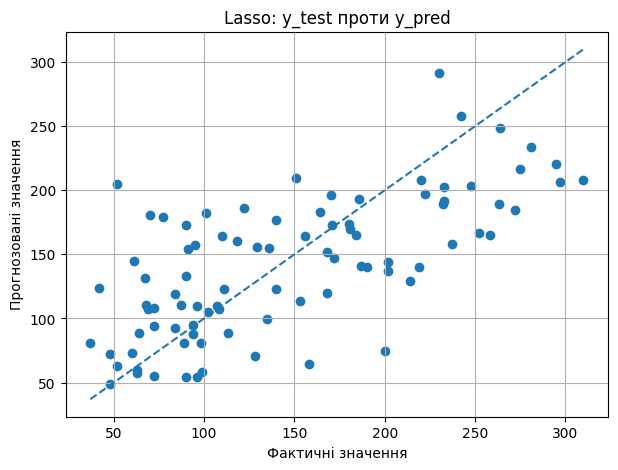

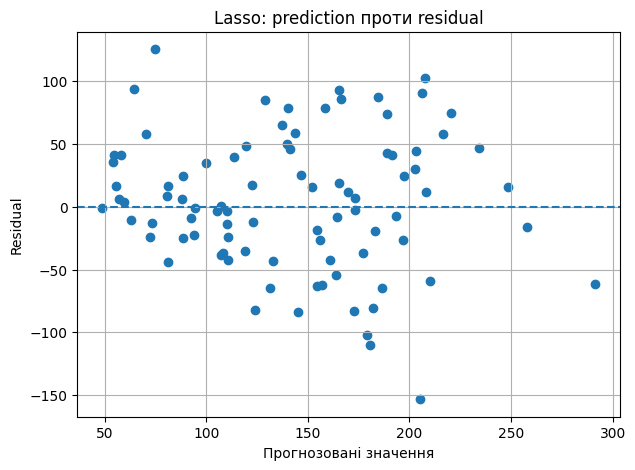

In [64]:
best_model_name = final_results_df['test RMSE'].idxmin()

print('Найкраща модель:', best_model_name)

if best_model_name == 'LinearRegression':
    best_model = linear_model
elif best_model_name == 'DummyRegressor':
    best_model = dummy_model
else:
    best_model = best_models[best_model_name]

y_pred_best = best_model.predict(X_test_task)

plt.figure(figsize=(7, 5))

plt.scatter(y_test_task, y_pred_best)

plt.xlabel('Фактичні значення')
plt.ylabel('Прогнозовані значення')
plt.title(f'{best_model_name}: y_test проти y_pred')

# Лінія ідеального прогнозу
min_value = min(y_test_task.min(), y_pred_best.min())
max_value = max(y_test_task.max(), y_pred_best.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.grid(True)
plt.show()

residuals = y_test_task - y_pred_best

plt.figure(figsize=(7, 5))

plt.scatter(y_pred_best, residuals)

plt.axhline(0, linestyle='--')

plt.xlabel('Прогнозовані значення')
plt.ylabel('Residual')
plt.title(f'{best_model_name}: prediction проти residual')

plt.grid(True)
plt.show()

### Крок 10. Коефіцієнти

In [72]:
if best_model_name in ['Ridge', 'Lasso', 'ElasticNet']:

    coefficients = best_model.named_steps['model'].coef_

    coefficients_df = pd.DataFrame({
        'Feature': X_task.columns,
        'Coefficient': coefficients
    })

    coefficients_df['AbsCoefficient'] = coefficients_df['Coefficient'].abs()

    coefficients_df = coefficients_df.sort_values(
        'AbsCoefficient',
        ascending=False
    )

    print(coefficients_df)

  Feature  Coefficient  AbsCoefficient
8      s5    29.632826       29.632826
4      s1   -29.358412       29.358412
2     bmi    25.824627       25.824627
3      bp    16.644252       16.644252
5      s2    13.275844       13.275844
1     sex   -11.316359       11.316359
7      s4    10.236168       10.236168
9      s6     2.393475        2.393475
0     age     1.730451        1.730451
6      s3     0.547948        0.547948


### Крок 11. Підсумковий висновок

У результаті проведеного дослідження найкращий результат показала модель Lasso. Вибір найкращої моделі виконано за метрикою RMSE на тестовій вибірці, причому менше значення RMSE відповідає кращій якості прогнозування. За отриманими результатами ознак суттєвого перенавчання моделі не спостерігається, оскільки результати крос-валідації та тестування не мають значного розходження. Використання регуляризації дозволило контролювати величину коефіцієнтів моделі та зменшити вплив менш важливих ознак. Зокрема, Lasso може зануляти окремі коефіцієнти, тому одночасно виконує регуляризацію та відбір ознак. Параметри регуляризації підбиралися за допомогою крос-валідації, а тестова вибірка при цьому не використовувалася. Це необхідно для того, щоб тестові дані залишалися незалежними та забезпечували об'єктивну оцінку здатності фінальної моделі працювати з новими даними.

## Контрольні питання після практики

1. Чому `StandardScaler` для Ridge/Lasso/Elastic Net доцільно розміщувати всередині `Pipeline`?
2. Чим відрізняється train-помилка від validation/test-помилки?
3. За якими ознаками можна розпізнати перенавчання?
4. Чим L1-регуляризація відрізняється від L2-регуляризації?
5. Чому `alpha` не можна підбирати за тестовою вибіркою?
6. Яку роль відіграє `l1_ratio` в Elastic Net?
7. Чому великий за модулем коефіцієнт не завжди означає, що ознака є найважливішою?
8. У чому перевага крос-валідації порівняно з одним випадковим validation-розбиттям?

In [ ]:
import pandas as pd
import requests
from io import StringIO

url = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C%22'

headers = {
"User-Agent": "Mozilla/5.0",
"Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(
StringIO(html),
match="Коефіцієнт народжуваності в регіонах України",
thousands=".", decimal=","
)[0]

df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0
